In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from scipy.optimize import curve_fit

import pickle

import schwingerModel as sim

In [3]:
def coshCorrel(nt, Energy, pivot,dimt):
    num = np.exp(-nt*Energy)+np.exp((nt-dimt)*Energy)
    denom = np.exp(-pivot*Energy)+np.exp((pivot-dimt)*Energy)
    return num/denom

In [4]:
with open('configs/50kSteps_scale_3.pkl', 'rb') as f:
    a3 = pickle.load(f)

with open('configs/50kSteps_scale_2.pkl', 'rb') as f:
    a2 = pickle.load(f)

with open('configs/50kSteps.pkl', 'rb') as f:
    a1 = pickle.load(f)

with open('configs/50kSteps_scale_0.5.pkl', 'rb') as f:
    a5 = pickle.load(f)


In [5]:
bIn = 0
skp = 50

gamma = np.array([[1j,0],[0,-1j]])

correl_a2 =  sim.distillation.correlStats(a2, burnIn=bIn,autocorrSkip=skp,Gamma=gamma)
correl_a1 =  sim.distillation.correlStats(a1, burnIn=bIn,autocorrSkip=skp,Gamma=gamma)
correl_a5 =  sim.distillation.correlStats(a5, burnIn=bIn,autocorrSkip=skp,Gamma=gamma)
correl_a3 =  sim.distillation.correlStats(a3, burnIn=bIn,autocorrSkip=skp,Gamma=gamma)

configs:   0%|          | 0/1000 [00:00<?, ?it/s]

configs:   0%|          | 0/1000 [00:00<?, ?it/s]

configs:   0%|          | 0/1000 [00:00<?, ?it/s]

configs:   0%|          | 0/1000 [00:00<?, ?it/s]

In [6]:
gamma = np.array([[1,0],[0,1]])

correl_a2_scalar =  sim.distillation.correlStats(a2, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,nVec=a2.dimx//2)
correl_a1_scalar =  sim.distillation.correlStats(a1, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,nVec=a1.dimx//2)
correl_a5_scalar =  sim.distillation.correlStats(a5, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,nVec=a5.dimx//2)
correl_a3_scalar =  sim.distillation.correlStats(a3, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,nVec=a3.dimx//2)

configs:   0%|          | 0/1000 [00:00<?, ?it/s]

configs:   0%|          | 0/1000 [00:00<?, ?it/s]

configs:   0%|          | 0/1000 [00:00<?, ?it/s]

configs:   0%|          | 0/1000 [00:00<?, ?it/s]

In [7]:
gamma = np.array([[1j,0],[0,-1j]])
correl_a5 =  sim.distillation.correlStats(a5, burnIn=bIn,autocorrSkip=skp//5,Gamma=gamma)
gamma = np.array([[1,0],[0,1]])
correl_a5_scalar =  sim.distillation.correlStats(a5, burnIn=bIn,autocorrSkip=skp//5,Gamma=gamma,nVec=a5.dimx//2)

configs:   0%|          | 0/5000 [00:00<?, ?it/s]

configs:   0%|          | 0/5000 [00:00<?, ?it/s]

(0.0, 50.0)

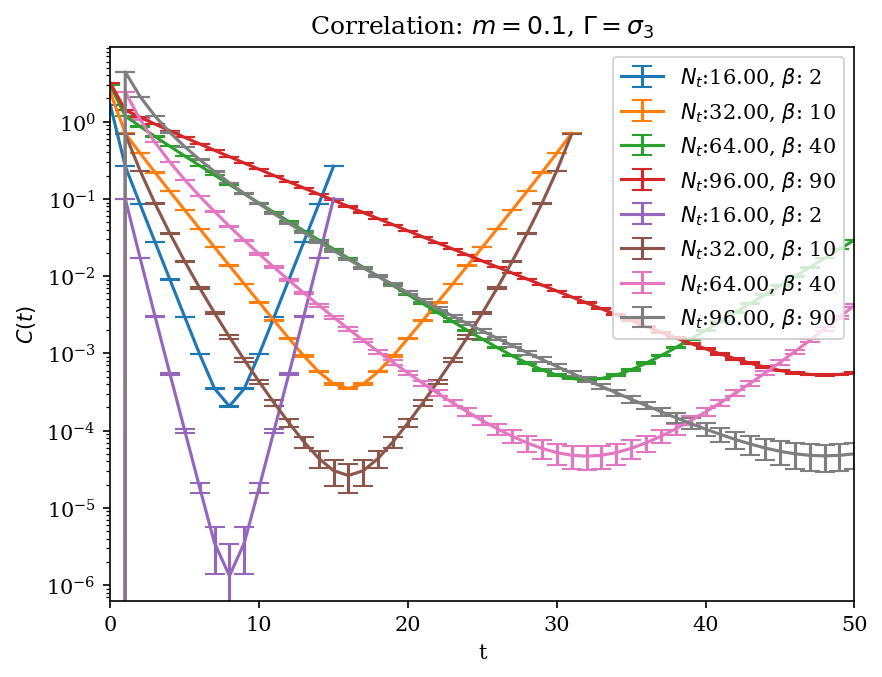

In [8]:
a2X = np.arange(a2.dimt)
a1X = np.arange(a1.dimt)
a5X = np.arange(a5.dimt)
a3X = np.arange(a3.dimt)    

initInd = 0

plt.figure(dpi=150)
plt.errorbar(x=a5X[initInd:], y=correl_a5[0], yerr=correl_a5[1],capsize=5, label=rf"$N_t$:{a5.dimt:.2f}, $\beta$: {a5.beta:.0f}")
plt.errorbar(x=a1X[initInd:], y=correl_a1[0], yerr=correl_a1[1],capsize=5, label=rf"$N_t$:{a1.dimt:.2f}, $\beta$: {a1.beta:.0f}")
plt.errorbar(x=a2X[initInd:], y=correl_a2[0], yerr=correl_a2[1],capsize=5, label=rf"$N_t$:{a2.dimt:.2f}, $\beta$: {a2.beta:.0f}")
plt.errorbar(x=a3X[initInd:], y=correl_a3[0], yerr=correl_a3[1],capsize=5, label=rf"$N_t$:{a3.dimt:.2f}, $\beta$: {a3.beta:.0f}")

plt.errorbar(x=a5X[initInd:], y=correl_a5_scalar[0], yerr=correl_a5_scalar[1],capsize=5, label=rf"$N_t$:{a5.dimt:.2f}, $\beta$: {a5.beta:.0f}")
plt.errorbar(x=a1X[initInd:], y=correl_a1_scalar[0], yerr=correl_a1_scalar[1],capsize=5, label=rf"$N_t$:{a1.dimt:.2f}, $\beta$: {a1.beta:.0f}")
plt.errorbar(x=a2X[initInd:], y=correl_a2_scalar[0], yerr=correl_a2_scalar[1],capsize=5, label=rf"$N_t$:{a2.dimt:.2f}, $\beta$: {a2.beta:.0f}")
plt.errorbar(x=a3X[initInd:], y=correl_a3_scalar[0], yerr=correl_a3_scalar[1],capsize=5, label=rf"$N_t$:{a3.dimt:.2f}, $\beta$: {a3.beta:.0f}")

plt.semilogy()
plt.legend()
plt.xlabel("t")
plt.ylabel(r"$C(t)$")
plt.title(rf"Correlation: $m={a2.fMass}$, $\Gamma=\sigma_3$")
plt.xlim(0,50)

In [9]:
a3_fitT = [30,48]
mass_a3 = sim.distillation.correlMassExtract(correl_a3,fitT=a3_fitT,diagCov=False)
a2_fitT = [15,33]
mass_a2 = sim.distillation.correlMassExtract(correl_a2,fitT=a2_fitT,diagCov=False)
a1_fitT = [5,17]
mass_a1 = sim.distillation.correlMassExtract(correl_a1,fitT=a1_fitT,diagCov=False)
a5_fitT = [3,8]
mass_a5 = sim.distillation.correlMassExtract(correl_a5,fitT=a5_fitT,diagCov=False)

a3_fitT = [30,48]
mass_a3_scalar = sim.distillation.correlMassExtract(correl_a3_scalar,fitT=a3_fitT,diagCov=False)
a2_fitT = [15,33]
mass_a2_scalar = sim.distillation.correlMassExtract(correl_a2_scalar,fitT=a2_fitT,diagCov=False)
a1_fitT = [5,17]
mass_a1_scalar = sim.distillation.correlMassExtract(correl_a1_scalar,fitT=a1_fitT,diagCov=False)
a5_fitT = [3,8]
mass_a5_scalar = sim.distillation.correlMassExtract(correl_a5_scalar,fitT=a5_fitT,diagCov=False)

In [10]:
scales = [1/.5,1,1/2,1/3]
masses = [mass_a5[0]*np.sqrt(a5.beta/10),mass_a1[0]*np.sqrt(a1.beta/10),mass_a2[0]*np.sqrt(a2.beta/10),mass_a3[0]*np.sqrt(a3.beta/10)]
massErr = [mass_a5[1]*np.sqrt(a5.beta/10),mass_a1[1]*np.sqrt(a1.beta/10),mass_a2[1]*np.sqrt(a2.beta/10),mass_a3[1]*np.sqrt(a3.beta/10)]

masses_scalar = [mass_a5_scalar[0]*np.sqrt(a5.beta/10),mass_a1_scalar[0]*np.sqrt(a1.beta/10),mass_a2_scalar[0]*np.sqrt(a2.beta/10),mass_a3_scalar[0]*np.sqrt(a3.beta/10)]
massErr_scalar = [mass_a5_scalar[1]*np.sqrt(a5.beta/10),mass_a1_scalar[1]*np.sqrt(a1.beta/10),mass_a2_scalar[1]*np.sqrt(a2.beta/10),mass_a3_scalar[1]*np.sqrt(a3.beta/10)]

In [11]:
def quad(a, mCont, c1, c2):
    return c2*a**2+c1*a+mCont
coeffs, cErr = curve_fit(quad, scales, masses, sigma=massErr, absolute_sigma=True)
coeffs_scalar, cErr_scalar = curve_fit(quad, scales, masses_scalar, sigma=massErr_scalar, absolute_sigma=True)

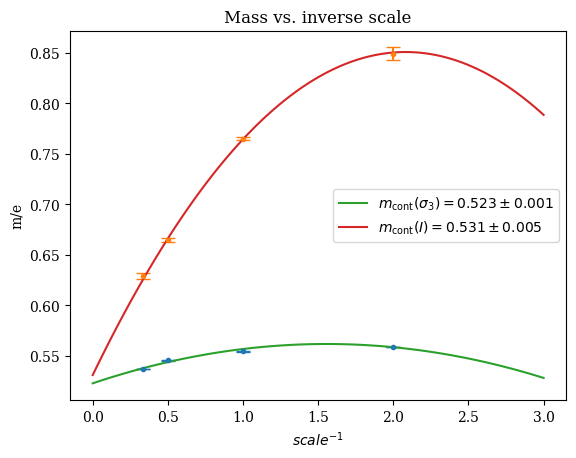

In [12]:
plt.errorbar(x=scales,y=masses, yerr= massErr,
                marker=".",ls="",capsize=5)
plt.errorbar(x=scales,y=masses_scalar, yerr= massErr_scalar,
                marker=".",ls="",capsize=5)

aFine = np.linspace(0,3,100)
plt.plot(aFine, quad(aFine, *coeffs),label=rf"$m_\text{{cont}}(\sigma_3) = {coeffs[0]:.3f}\pm{np.sqrt(cErr[0,0]):.3f}$")
plt.plot(aFine, quad(aFine, *coeffs_scalar),label=rf"$m_\text{{cont}}(I) = {coeffs_scalar[0]:.3f}\pm{np.sqrt(cErr_scalar[0,0]):.3f}$")

plt.xlabel("$scale^{-1}$")
plt.ylabel("m/e")
plt.title(rf"Mass vs. inverse scale")
plt.legend()

In [22]:
am = np.array([mass_a5[0],mass_a1[0],mass_a2[0],mass_a3[0]]) 

chargePerMass = np.array([mass_a5[0]*np.sqrt(a5.beta/10),mass_a1[0]*np.sqrt(a1.beta/10),mass_a2[0]*np.sqrt(a2.beta/10),mass_a3[0]*np.sqrt(a3.beta/10)])**(-1)
chargePerMassErr = np.array([mass_a5[1]*np.sqrt(a5.beta/10),mass_a1[1]*np.sqrt(a1.beta/10),mass_a2[1]*np.sqrt(a2.beta/10),mass_a3[1]*np.sqrt(a3.beta/10)])/chargePerMass**(-2)

am_scalar = np.array([mass_a5_scalar[0],mass_a1_scalar[0],mass_a2_scalar[0],mass_a3_scalar[0]])
chargePerMass_scalar = np.array([mass_a5_scalar[0]*np.sqrt(a5.beta/10),mass_a1_scalar[0]*np.sqrt(a1.beta/10),mass_a2_scalar[0]*np.sqrt(a2.beta/10),mass_a3_scalar[0]*np.sqrt(a3.beta/10)])**(-1)
chargePerMassErr_scalar = np.array([mass_a5_scalar[1]*np.sqrt(a5.beta/10),mass_a1_scalar[1]*np.sqrt(a1.beta/10),mass_a2_scalar[1]*np.sqrt(a2.beta/10),mass_a3_scalar[1]*np.sqrt(a3.beta/10)])/chargePerMass_scalar**(-2)

In [23]:
am_scalar/am

array([1.52068937, 1.38073615, 1.21810581, 1.17242148])

In [18]:
chargePerMass_scalar/chargePerMass

array([0.6575965 , 0.72425134, 0.82094674, 0.85293558])

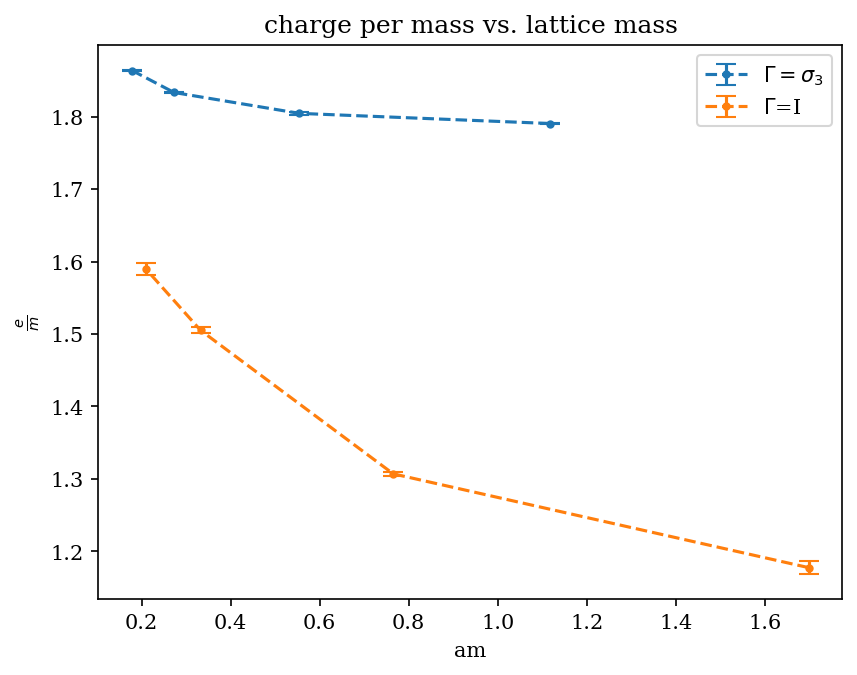

In [16]:
plt.figure(dpi=150)
plt.errorbar(x=am, y=chargePerMass,yerr=chargePerMassErr,capsize=5,ls="--",marker=".",label=r"$\Gamma=\sigma_3$")
plt.errorbar(x=am_scalar, y=chargePerMass_scalar,yerr=chargePerMassErr_scalar,capsize=5,ls="--",marker=".",label=r"$\Gamma$=I")
plt.xlabel("am")
plt.ylabel(r"$\frac{e}{m}$")
plt.title("charge per mass vs. lattice mass")
plt.legend()

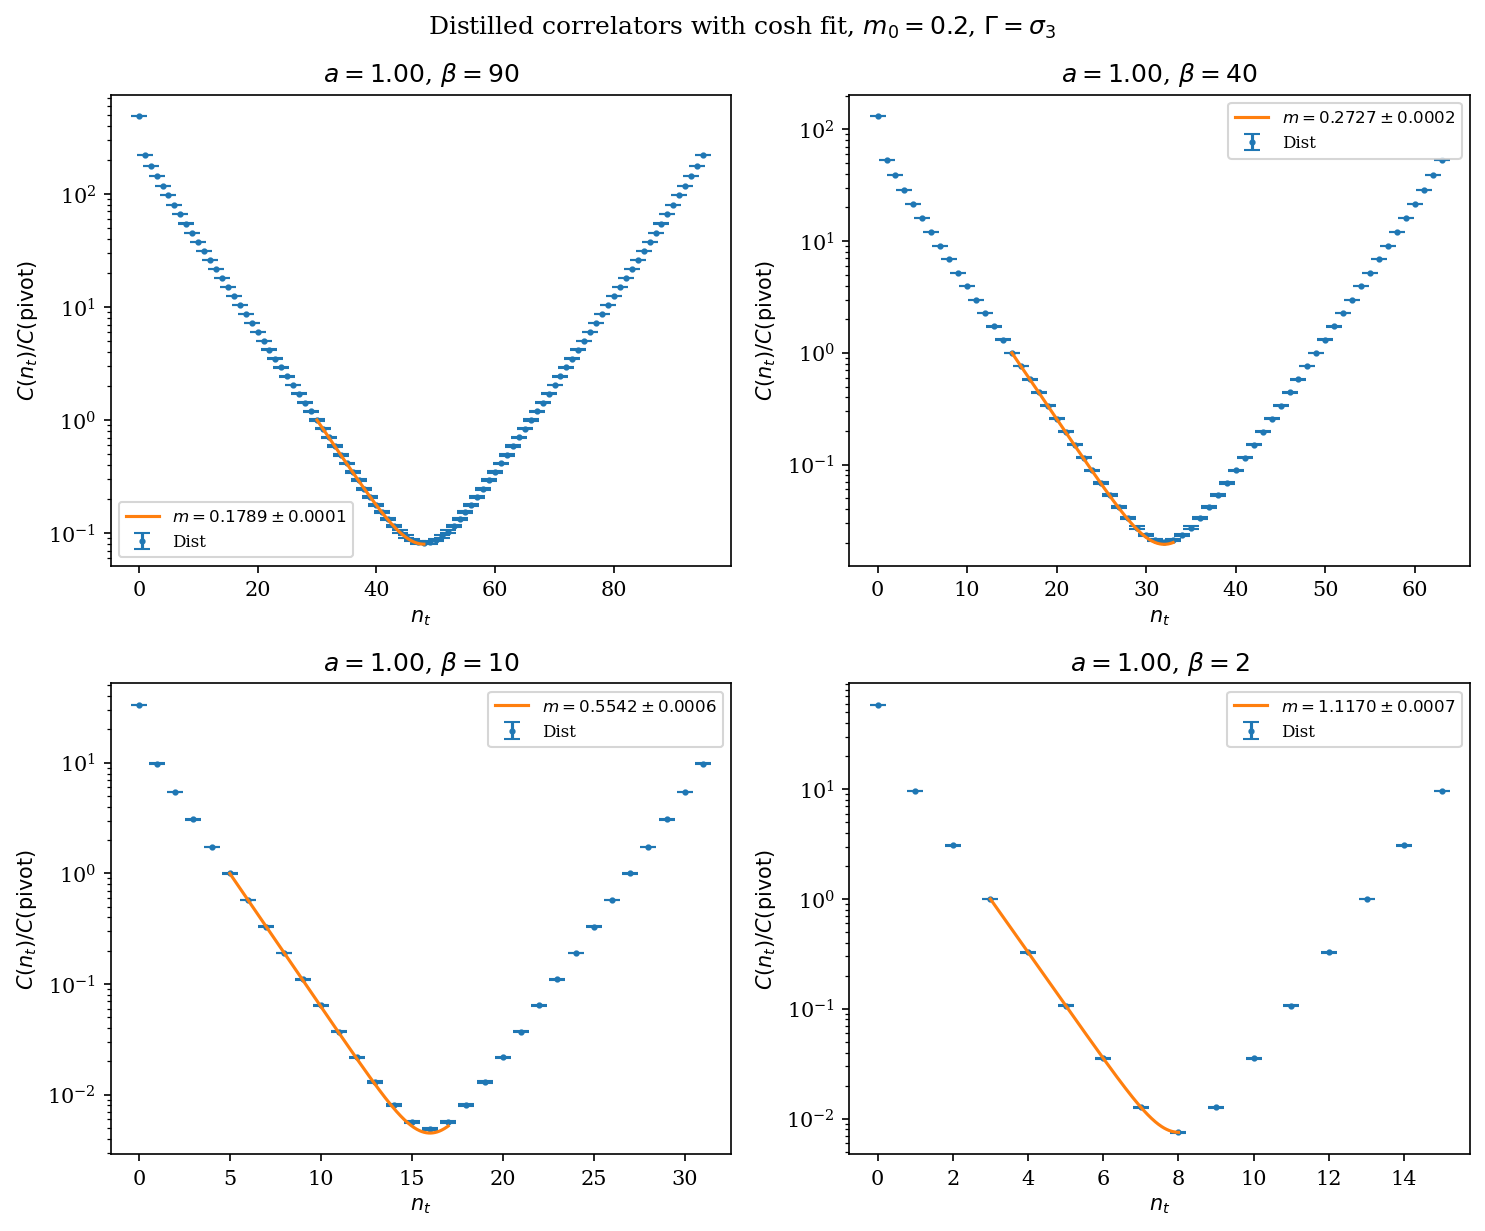

In [17]:
def coshCorrel(nt, Energy, pivot, dimt):
    num = np.exp(-nt * Energy) + np.exp((nt - dimt) * Energy)
    denom = np.exp(-pivot * Energy) + np.exp((pivot - dimt) * Energy)
    return num / denom

configs = [
    (a3,  correl_a3,  mass_a3,  a3_fitT[0],  a3_fitT[1]),
    (a2,  correl_a2,  mass_a2,  a2_fitT[0],  a2_fitT[1]),
    (a1,  correl_a1,  mass_a1,  a1_fitT[0],  a1_fitT[1]),
    (a5,  correl_a5,  mass_a5,  a5_fitT[0], a5_fitT[1])
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=150)

for ax, (model, correl, mass, pivot, fitEnd) in zip(axes.flat, configs):
    dimt = len(correl[0])

    nt_data = np.arange(dimt)
    nt_fine = np.linspace(pivot, fitEnd, 300)

    norm = correl[0][pivot]

    ax.errorbar(nt_data, correl[0] / norm, yerr=correl[1] / norm,
                fmt='.', capsize=4, markersize=4, label='Dist',zorder=0)
    ax.plot(nt_fine, coshCorrel(nt_fine, mass[0], pivot, dimt),
            label=rf'$m = {mass[0]/model.a:.4f} \pm {mass[1]/model.a:.4f}$',zorder=1)
    ax.set_yscale('log')
    ax.set_xlabel(r'$n_t$')
    ax.set_ylabel(r'$C(n_t) / C(\mathrm{pivot})$')
    ax.set_title(rf'$a = {model.a:.2f}$, $\beta = {model.beta:.0f}$')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle(rf'Distilled correlators with cosh fit, $m_0 = {a1.fMass}$, $\Gamma = \sigma_3$', y=1.02)
plt.show()